# **Détection de contours**
### **A rendre avant le 13 mars à 23h:59mn sur Chamillo. Utilisation des LLMs est fortement déconseillée.**

##### ***N'oubliez pas de preciser vos Nom et Prenom comme nom du ficher notebook***

***NB: Essayez de commenter les codes le plus possible et aussi (recommendé) de commenter les erreurs rencontrées et qui vous ont fait galérer le plus. Precisier comment vous avez compris ces erreurs et comment vous avez fait pour les corriger. Cette partie sera plus considérée dans la correction que la solution bien faite.***


Les frontières qui séparent les régions homogènes occupent une part importante dans le système
visuel humain. On peut définir un contour comme une variation brutale de niveau de gris, plus ou moins
entachée de bruit. Les neuro-physiologistes pensent que le système visuel humain commence par effectuer
une détection de contour, certaines zones neuronales se spécialisant dans la détection dans des directions
précises à l’aide de plusieurs lissages de tailles différentes.
D’un point de vue formel, en 2D, un contour est une rupture entre 2 surfaces de valeurs à peu près
constantes : frontière entre 2 objets réels, entre 2 couleurs par exemple.

Les contours peuvent être détectés par un examen des grandeurs étudiées (niveau de gris, distance,
couleur, ...) soit :
* par des opérateurs locaux de différentiation du premier ordre
* par des opérateurs locaux de différentiation du second ordre
* par des opérations ensemblistes (Morphologie mathématique).

L’objectif de cette partie est de comparer les 2 premières approches qualitativement.

Vous devrez utilisez les trois images mandril256.pgm, einstein.pgm et moroe.pgm dans imagestp/

Pour cette séance le support théorique dans https://chamilo.grenoble-inp.fr/ (ENSIMAG 4MMTI6 Traitement d'image/Documents/TP/TP1/tp1.pdf) "section 2. detection de contours" est important.

Les fonctions implmenté durant le TP1 vous seront utiles pour ce TP.

# 1 - Opérateur du premier ordre - Calcul du gradient et seuillage du module du gradient

Objectif: Implémentez une fonction en Python pour calculer le gradient d'une image en utilisant des opérateurs du premier ordre (par exemple, Sobel) et appliquez un seuillage du module du gradient pour détecter les contours. Appliquez les sur Mandrill.

1. Calculez le gradient de l'image en utilisant un filtre de Sobel tel que décrit dans "2.2.1 Gradient discret". Vous pourrez utiliser les fonctions du TP1 pour appliquer une convolution spatiale. 
2. Définissez la fonction detect_contours_first_order en a) calculant le gradient et b) seuillant le module du gradient.
3. Testez sur les images fournies et visualisez les résultats pour différentes valeurs de seuil et interprétez.

/opt/python-ensimag/lib/python3.12/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


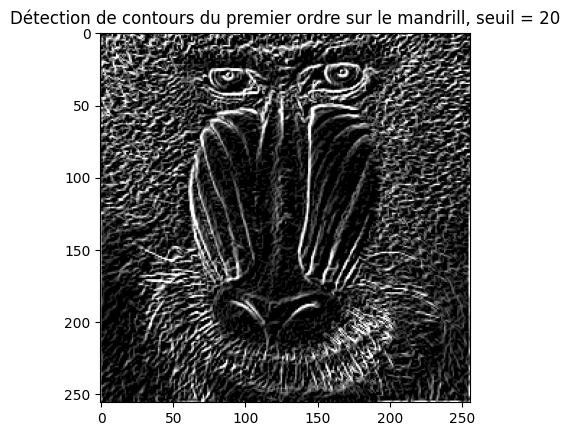

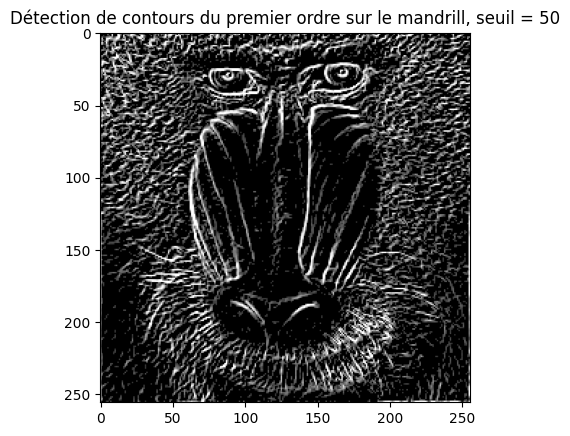

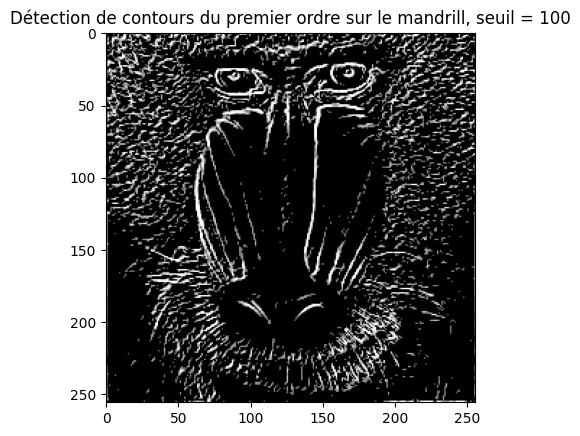

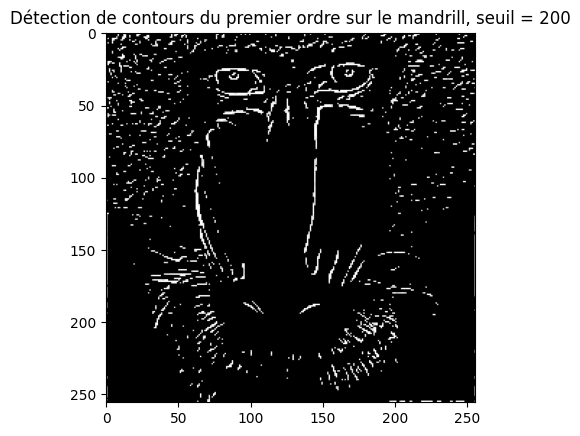

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import skimage.io as io

def apply_filter(image, kernel, clip=True):
    n = int((kernel.shape[0]-1)/2)

    pad_image = np.pad(image, n, mode='wrap')
    filtered_image = np.zeros(image.shape, dtype='float')
    
    for x in range(image.shape[0]):
        for y in range(image.shape[1]):
            filtered_image[x,y] = np.sum(pad_image[x:x+2*n+1,y:y+2*n+1]*kernel)

    if clip:
        filtered_image = np.clip(filtered_image, 0, 255)
        
    return filtered_image

def detect_contour_first_order(image, seuil):

    M1 = np.array([[-1,0,1],[-2,0,2],[-1,0,1]])
    M2 = M1.T

    Gx = apply_filter(image, M1)
    Gx = Gx.astype(np.float32)
    
    Gy = apply_filter(image, M2)
    Gy = Gy.astype(np.float32)
    
    norme_grad = np.sqrt(Gx**2 + Gy**2)

    image_contours = np.clip(np.where(norme_grad < seuil, 0, norme_grad),0,255)

    return image_contours

mandrill = io.imread("mandrill256.pgm")

contours_mandrill_1 = detect_contour_first_order(mandrill, 20)
plt.imshow(contours_mandrill_1, cmap='gray')
plt.title("Détection de contours du premier ordre sur le mandrill, seuil = 20")
plt.show()
contours_mandrill_50 = detect_contour_first_order(mandrill, 50)
plt.imshow(contours_mandrill_50, cmap='gray')
plt.title("Détection de contours du premier ordre sur le mandrill, seuil = 50")
plt.show()
contours_mandrill_100 = detect_contour_first_order(mandrill, 100)
plt.imshow(contours_mandrill_100, cmap='gray')
plt.title("Détection de contours du premier ordre sur le mandrill, seuil = 100")
plt.show()
contours_mandrill_200 = detect_contour_first_order(mandrill, 200)
plt.imshow(contours_mandrill_200, cmap='gray')
plt.title("Détection de contours du premier ordre sur le mandrill, seuil = 200")
plt.show()

On remarque que les contours du mandrill ressortent franchement. On remarque aussi que plus le seuil est grand, moins les contours sont détaillés, mais plus ils sont francs. C'est normal, si le seuil est grand on affiche uniquement les pixels dont le gradient est très grand. 

Pour cette question j'ai eu des problème de dtype : lorsque je prenais le carré de mes listes j'avais toujours des valeurs entre 0 et 255, ce qui posat problème. J'ai donc changé le Dtype dans mes arrays numpy pour float et ça a fonctionné.

# 2 - Opérateur du deuxième ordre - Calcul du laplacien et extraction des contours par passage par zéro

Objectif : Implémentez une fonction en Python pour calculer le laplacien d'une image et extrayez les contours en utilisant le passage par zéro du laplacien

1. Calculez le laplacien de l'image en appliquant l'un des trois filtres donnés dans "2.3.1 Laplacien discret". Vous pourrez utiliser la fonction précédente pour appliquer une convolution spatiale.

2. Définissez la fonction detect_contours_second_order en a) calculant le laplacien et b) détectant les passages par zéro tel que décrit dans "2.3.5 Extraction des contours".

3. Testez sur les images fournies et visualisez les résultats. Que remarquez-vous ?

4. Appliquez un lissage gaussien, puis effectuez la détection de contours avec le passage à zéro du laplacien ; vous pourrez utiliser les fonctions du TP1 pour appliquer un lissage gaussien. Comparez avec les résultats précédents, que remarquez-vous ?

5. La question 4 revient à appliquer un filtre LoG : Laplacian of Gaussian, tel que décrit dans "2.3.1 Laplacien discret". Implémentez une fonction qui calcule ce filtre et appliquez ce dernier sur les images fournies pour la détection de contours. Quel est l'avantage d'utiliser le filtre LoG au lieu de lisser l'image et ensuite d'effectuer le calcul du laplacien ?

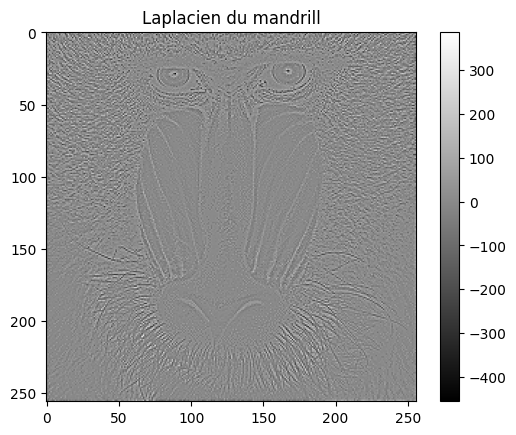

In [2]:
#question 1
def calculate_laplacien(image):
    
    kernel = np.array([[0,1,0],
                       [1,-4,1],
                       [0,1,0]],dtype = 'float')

    return apply_filter(image,kernel, clip = False)
    

laplacien_image = calculate_laplacien(mandrill)
plt.imshow(laplacien_image, cmap='gray')
plt.title("Laplacien du mandrill")
plt.colorbar()
plt.show()

Pour cette question j'ai d'abord utilisé naïvement ma fonction apply_filter, mais j'ai eu des erreurs car le np.clip( ..., 0, 255) supprimait les valeurs négatives du Laplacien, essentielles pour la détection de contours. J'ai donc modifié cette fonction en ajoutant un booléen qui contrôle le clip

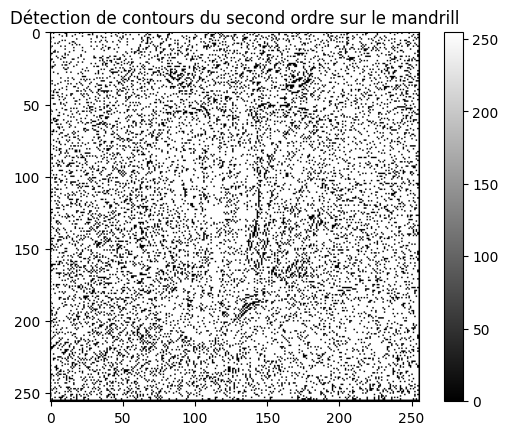

In [3]:
#question 2
def detect_contours_second_order(image):
    laplacien_image = calculate_laplacien(image)
    contours = np.zeros_like(image)

    for i in range(image.shape[0]-1):
        for j in range(image.shape[1]-1):
            if laplacien_image[i,j] * laplacien_image[i+1,j] <= 0 or laplacien_image[i,j] * laplacien_image[i,j+1] <= 0:
                contours[i,j] = 255

    return contours

contours_laplacien = detect_contours_second_order(mandrill)
plt.imshow(contours_laplacien, cmap='gray')
plt.title("Détection de contours du second ordre sur le mandrill")
plt.colorbar()
plt.show()

On remarque que les contours n'apparaîssent pas franchement. On les distingue à peine, mais ce n'est pas satisfaisant. C'est probablement à cause du bruit. En effet, s'il y a du bruit l'intensité de l'image oscille entre chaque pixel, un peu comme la sinusoïde bruitée du TP1. Etudier la dérivée et détecter un contour à chaque fois qu'elle change de signe génère donc beaucoup trop de contours. Peut-être que cette méthode pourrait être efficace avec moins de bruit.

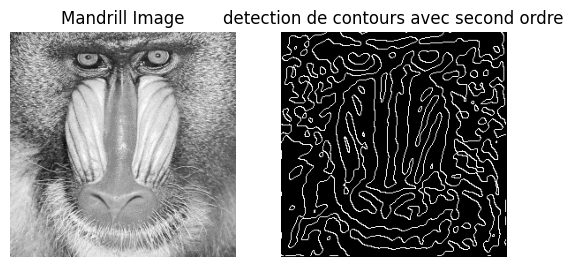

In [4]:
#Question 4
def gaussian_2d_fourier(N, M, sigma):

    #au début je pensais utiliser np.zeros((N,M)), puis faire une double boucle for
    #mais au final il est baeucoup plus efficace de faire deux matrices avec np.meshgrid
    #puis de calculer le terme sur u, puis sur v, puis de mettre les deux au carré, puis additioner et lever à l'exp

    # Créer une grille de taille N, M, vous pourrez utiliser np.meshgrid
    v,u = np.meshgrid(np.arange(0, M), np.arange(0,N))                  
    
    # Appliquer la formule
    tf_gaussian = np.exp(-2*(np.pi)**2*sigma**2*( ((u-N/2)/N)**2 + ((v-M/2)/M)**2 ))

    return tf_gaussian 

def frequency_gaussian_filter(image, sigma):
    
    
    tf_image = np.fft.fftshift(np.fft.fft2(image))
    tf_gaussian = gaussian_2d_fourier(image.shape[0], image.shape[1], sigma)

    #au début j'avais oublié de déshifter l'image avant de faire ifft2, j'ai eu des problèmes
    filtered_image = np.fft.ifft2(np.fft.ifftshift(tf_image*tf_gaussian))
    return np.abs(filtered_image), tf_gaussian

gaussian_mandrill,_ = frequency_gaussian_filter(mandrill, 4)
contours_gaussian_mandrill = detect_contours_second_order(gaussian_mandrill)
plt.subplot(1, 2, 1)
plt.imshow(mandrill, cmap='gray')
plt.title('Mandrill Image')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(contours_gaussian_mandrill, cmap='gray')
plt.title('detection de contours avec second ordre')
plt.axis('off')

plt.show()


Après lissage par filtre gaussien, la détection des contours est beaucoup plus efficace. On remarque que les contours apparîssent franchement. Toutefois, au niveau des moustaches, on voit qu'on a perdu en détail, dû probablement au flou gaussien. On doit donc trouver un compromis sur sigma entre la réduction du bruit et la détection des contours

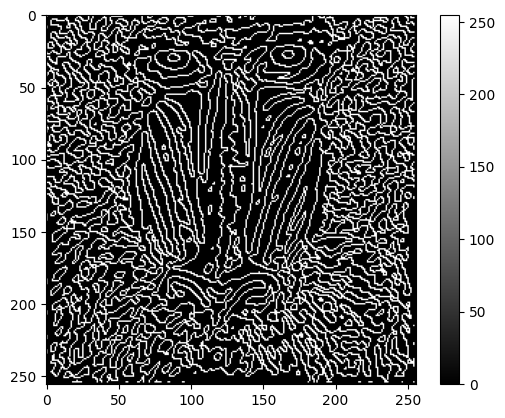

In [5]:
#Question 5
def detect_contours_laplacian_of_gaussian(image, sigma):
    N = image.shape[0]
    M = image.shape[1]

    y,x = np.meshgrid(np.arange(-M//2, M//2 + M%2),np.arange(-N//2, N//2 + N%2))

    frac = (x**2 + y**2)/2/sigma**2

    filtre_spatial = 1/np.pi/sigma**4 * (frac - 1)*np.exp(-frac)

    filtre_frequentiel = np.fft.fft2(filtre_spatial)

    gaussian_image_laplacien = np.fft.fftshift(np.fft.ifft2( filtre_frequentiel * np.fft.fft2(image)))
    
    contours = np.zeros_like(image)
    
    for i in range(gaussian_image_laplacien.shape[0]-1):
        for j in range(gaussian_image_laplacien.shape[1]-1):
            if gaussian_image_laplacien[i,j] * gaussian_image_laplacien[i+1,j] <= 0 or gaussian_image_laplacien[i,j] * gaussian_image_laplacien[i,j+1] <= 0:
                contours[i,j] = 255

    return contours

contours_mandrill_LoG = detect_contours_laplacian_of_gaussian(mandrill, 2)
plt.imshow(contours_mandrill_LoG, cmap='gray')
plt.colorbar()
plt.show()

En effet on obtient un résultat similaire. Concernant l'intéret de cetté méthode, en effet on fait donc une seule convolution au lieu d'une convolution et une FFT précedemment. Toutefois, pour obtenir un bon flou gaussien, il faut un kernel de taile supérieure à 3, la taille de celui utilisé précedemment. Donc la convolution prend certainement plus de temps que le filtre d'avant. 

C'est pour cela que j'ai décidé de prendre la FFT du filtre spatial donné, pour faire directement la multiplication en fréquentiel, ce qui est plus rapide. 

# 3 - Comparaison qualitative

* Comparez les détections/extractions de contours obtenues avec l'opérateur du premier ordre (gradient) et celui du deuxième ordre (LoG) d'un point de vue qualitatif. Affichez des résultats sur les images fournies côte à côte.

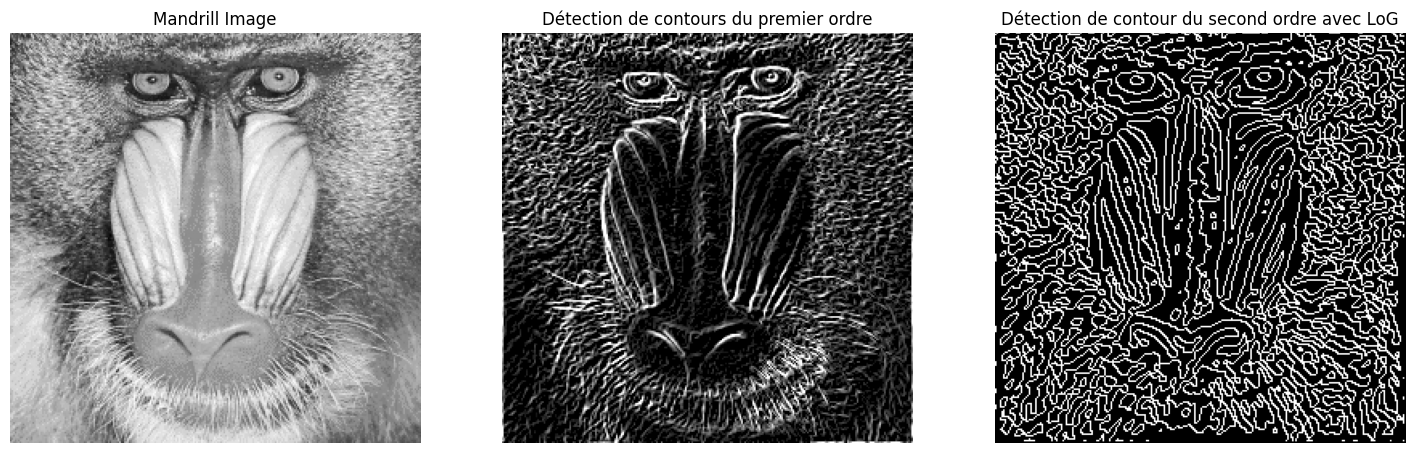

In [6]:
plt.figure(figsize=(18, 6))

plt.subplot(1, 3, 1)
plt.imshow(mandrill, cmap='gray')
plt.title('Mandrill Image')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(contours_mandrill_1, cmap='gray')  # Log scale for visibility
plt.title('Détection de contours du premier ordre')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(contours_mandrill_LoG, cmap='gray')
plt.title(f'Détection de contour du second ordre avec LoG')
plt.axis('off')

plt.show()

# 4 - Opérateurs laplacien, DOG, lissage et FFT:
* Approximez le laplacien de Gaussienne par la différence entre deux lissages tel que décrit dans "2.3.2 DOG : Différence Of Gaussian". Testez et visualisez sur les images fournies.
* Implémentez une détection de contours dans le domaine fréquentiel telle que décrite dans "2.3.3 Opérateurs laplacien, lissage et FFT". Testez et visualisez sur les images fournies.

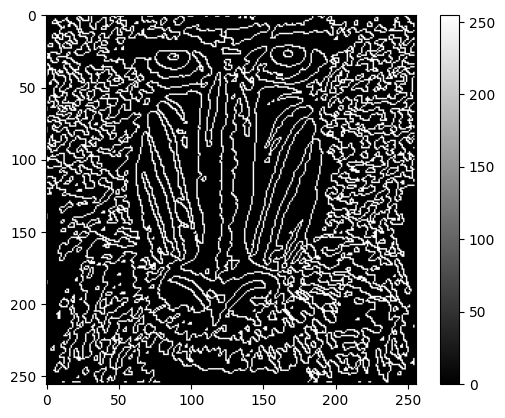

In [7]:
def detect_contours_DoG(image, sigma1, sigma2):
    gaussian_image_1, _ = frequency_gaussian_filter(image, sigma1)
    gaussian_image_2, _ = frequency_gaussian_filter(image, sigma2)
    diff = gaussian_image_1-gaussian_image_2

    contours = np.zeros_like(diff)

    for i in range(diff.shape[0]-1):
        for j in range(diff.shape[1]-1):
            if diff[i,j] * diff[i+1,j] <= 0 or diff[i,j] * diff[i,j+1] <= 0:
                contours[i,j] = 255

    return contours

mandrill_DoG = detect_contours_DoG(mandrill, 1,6)
plt.imshow(mandrill_DoG, cmap='gray')
plt.colorbar()
plt.show()

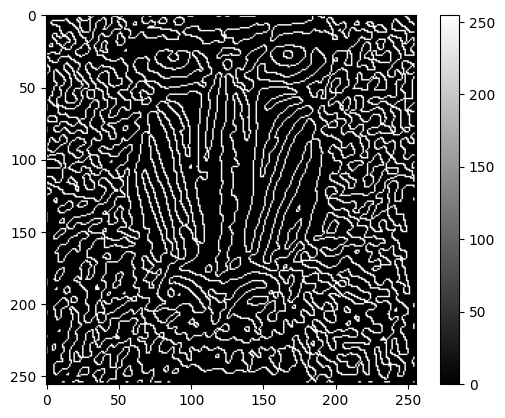

In [8]:
#Question 5
def detect_contours_laplacian_of_gaussian_TF(image, sigma):
    N = image.shape[0]
    M = image.shape[1]

    v,u = np.meshgrid(np.arange(-M//2, M//2 + M%2),np.arange(-N//2, N//2 + N%2))

    R = (u**2 + v**2)

    filtre_frequentiel = -4*np.pi**2 *R*np.exp(-2*np.pi**2*sigma**2*R)
    
    gaussian_image_laplacien = np.fft.ifft2( np.fft.fftshift(filtre_frequentiel) * np.fft.fft2(image))
    
    contours = np.zeros_like(image)
    
    for i in range(gaussian_image_laplacien.shape[0]-1):
        for j in range(gaussian_image_laplacien.shape[1]-1):
            if gaussian_image_laplacien[i,j] * gaussian_image_laplacien[i+1,j] <= 0 or gaussian_image_laplacien[i,j] * gaussian_image_laplacien[i,j+1] <= 0:
                contours[i,j] = 255

    return contours

contours_mandrill_LoG_TF = detect_contours_laplacian_of_gaussian_TF(mandrill, 0.01)
plt.imshow(contours_mandrill_LoG_TF, cmap='gray')
plt.colorbar()
plt.show()

Cette fonction implémente le LoG en fréquentiel directement, similarement à celui que j'ai fait dans la question 3. C'est la manière la plus efficace de faire.